# Judge Comparisons - Thesis-Quality ROC-AUC Analysis

This notebook provides a comprehensive comparative analysis of judge architectures using ROC-AUC curves.
Each judge's binary classifications are evaluated against continuous reference metrics (ROUGE-L and F1) to assess 
discriminative capability. Visualizations follow Storytelling with Data principles for thesis presentation.

In [4]:
import polars as pl
import matplotlib.pyplot as plt
from sklearn import metrics
import os

# Define paths
BINARY_COLLECTIONS_PATH = "../binary_collections"
REFERENCE_COLLECTIONS_PATH = "../reference_collections"

# Judge names mapping
JUDGES = {
    "naive": "Naive Judge",
    "pairwise_rag": "Pairwise RAG",
    "pairwise_zeroshot": "Pairwise ZeroShot",
    "voting_naive": "Voting Naive"
}

print("Environment setup complete.")

Environment setup complete.


## Load ROUGE-L Reference Collection

Load the continuous ROUGE-L scores that will be used as the ground truth for all ROC-AUC computations.


In [ ]:
# Load ROUGE-L continuous collection and sort by collection_idx and test_idx
rougel_path = os.path.join(REFERENCE_COLLECTIONS_PATH, "rougel_collection", "train.feather")
rougel_df = pl.read_ipc(rougel_path).sort("collection_idx", "test_idx")

print(f"ROUGE-L collection loaded: {rougel_df.shape}")
print(f"Columns: {rougel_df.columns}")
rougel_df.head()

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


ROUGE-L collection loaded: (6925000, 4)
Columns: ['collection_idx', 'test_idx', 'input', 'evaluation']


collection_idx,test_idx,input,evaluation
i64,i64,"array[i64, 100]",f64
0,0,"[0, 0, … 0]",1.0
0,1,"[0, 0, … 0]",0.0
0,2,"[0, 0, … 0]",0.0
0,3,"[0, 0, … 0]",0.0
0,4,"[0, 0, … 0]",0.0


## Helper Function for ROC-AUC Computation

Define a function that properly handles data alignment (sorting and joining) before computing ROC-AUC scores.


In [ ]:
def compute_roc_auc_with_alignment(judge_df, rougel_reference_df):
    """
    Compute ROC-AUC with proper data alignment.
    
    Parameters:
    -----------
    judge_df : polars.DataFrame
        Binary judge classifications with columns: collection_idx, test_idx, evaluation
    rougel_reference_df : polars.DataFrame
        Continuous ROUGE-L scores with columns: collection_idx, test_idx, evaluation (or similar)
    
    Returns:
    --------
    tuple : (roc_auc_score, fpr, tpr, thresholds)
    """
    # Sort both dataframes
    judge_sorted = judge_df.sort("collection_idx", "test_idx")
    rougel_sorted = rougel_reference_df.sort("collection_idx", "test_idx")
    
    # Join on collection_idx and test_idx (inner join to keep only aligned records)
    merged_df = judge_sorted.join(
        rougel_sorted.select(["collection_idx", "test_idx", "evaluation"]).rename({"evaluation": "rougel_score"}),
        on=["collection_idx", "test_idx"],
        how="inner"
    )
    
    # Extract labels and scores
    y_true = merged_df["evaluation"].to_list()  # Binary judge labels
    y_scores = merged_df["rougel_score"].to_list()  # Continuous ROUGE-L scores
    
    # Calculate ROC-AUC
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
    roc_auc = metrics.auc(fpr, tpr)
    
    return roc_auc, fpr, tpr, thresholds

print("Helper function defined.")

Helper function defined.


## Individual Judge Performance Analysis

### ROUGE-L Reference Evaluation

This section evaluates each judge's ability to distinguish between high-quality (ROUGE-L ≥ threshold) 
and lower-quality contexts. ROUGE-L provides a reference signal based on lexical overlap with gold passages.


Processing: Naive Judge
Judge data loaded: (6095180, 7)
ROC-AUC Score: 0.6722

Processing: Pairwise RAG
Judge data loaded: (5484448, 7)
ROC-AUC Score: 0.5560

Processing: Pairwise ZeroShot
Judge data loaded: (7606286, 7)
ROC-AUC Score: 0.5685

Processing: Voting Naive
Judge data loaded: (20287193, 7)


/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


ROC-AUC Score: nan


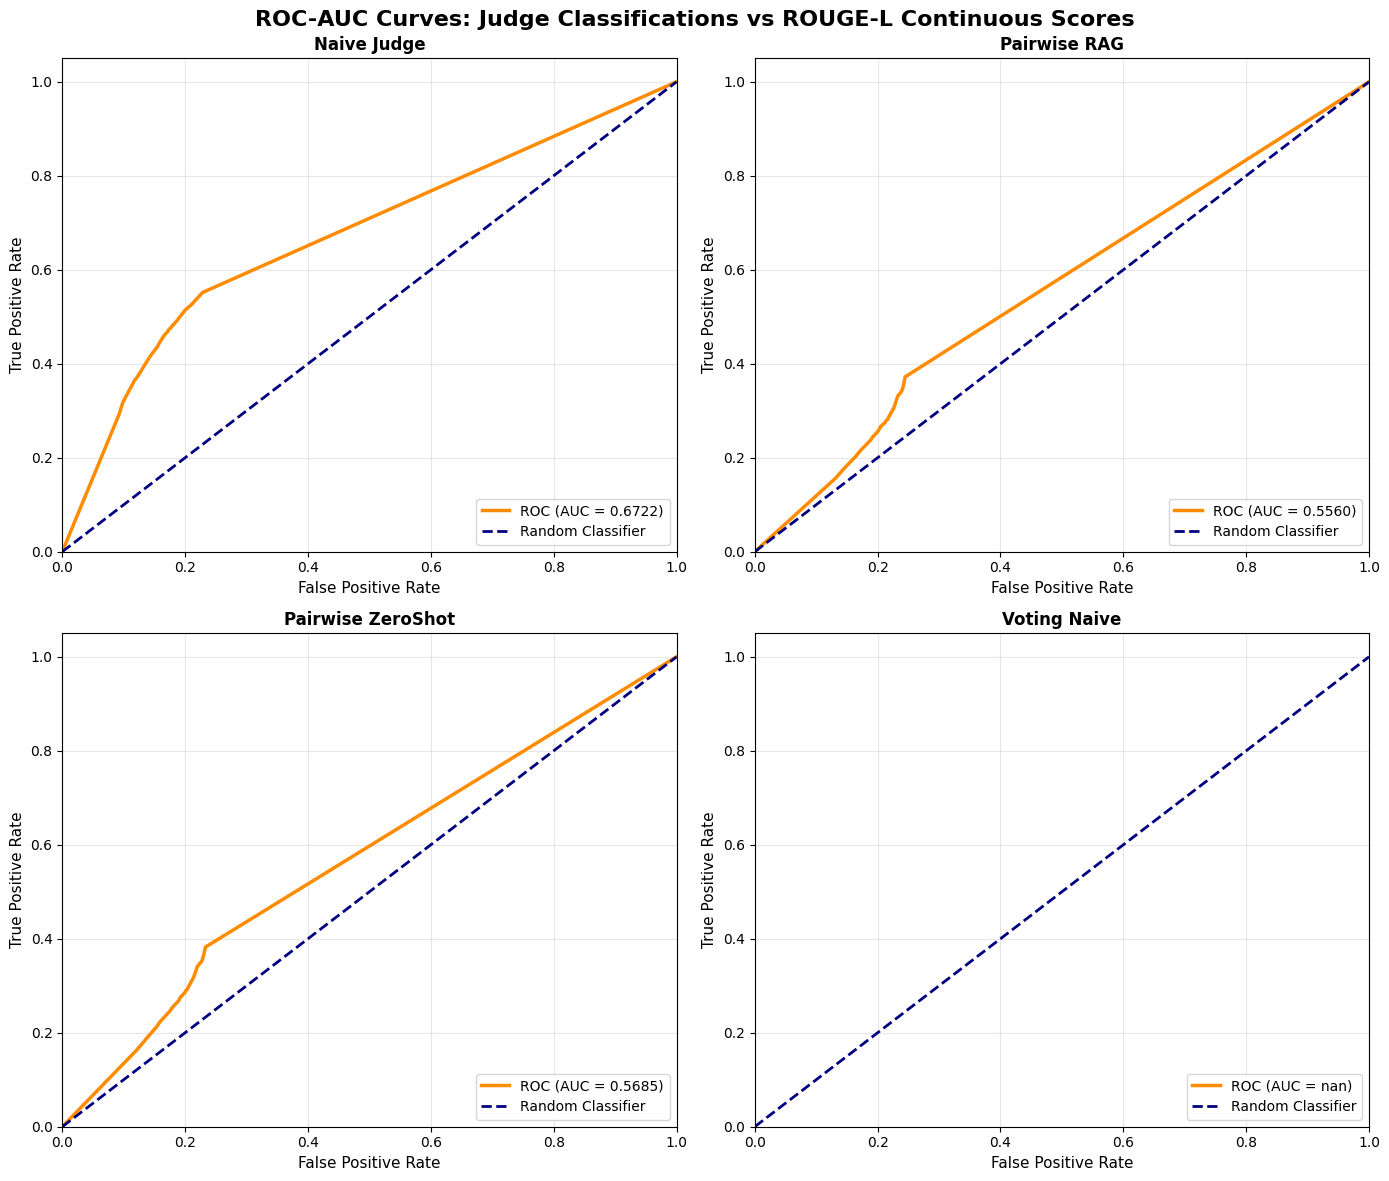


AUC Scores Summary:
Naive Judge               → 0.6722
Pairwise RAG              → 0.5560
Pairwise ZeroShot         → 0.5685
Voting Naive              → nan


In [ ]:
# Create 2x2 grid for ROC-AUC curves with thesis-quality improvements
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Judge Performance Against ROUGE-L Reference Scores\nROC-AUC Curves Across Four Judge Architectures", 
             fontsize=14, fontweight='bold', y=0.995)

# Professional color palette - distinct but thesis-appropriate
colors = {'naive': '#1f77b4', 'pairwise_rag': '#ff7f0e', 
          'pairwise_zeroshot': '#2ca02c', 'voting_naive': '#d62728'}

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Define judge keys and their positions in the grid
judge_keys = list(JUDGES.keys())
auc_results = {}

# Process each judge
for idx, judge_key in enumerate(judge_keys):
    print(f"\n{'='*60}")
    print(f"Processing: {JUDGES[judge_key]}")
    print(f"{'='*60}")
    
    # Load judge's binary collection
    judge_path = os.path.join(BINARY_COLLECTIONS_PATH, judge_key, "train.feather")
    judge_df = pl.read_ipc(judge_path).filter(pl.col("evaluation").is_not_null())
    
    print(f"Judge data loaded: {judge_df.shape}")
    
    # Compute ROC-AUC with proper alignment
    roc_auc, fpr, tpr, thresholds = compute_roc_auc_with_alignment(judge_df, rougel_df)
    
    # Store results
    auc_results[judge_key] = roc_auc
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    
    # Plot on corresponding subplot
    ax = axes_flat[idx]
    judge_color = colors[judge_key]
    
    # Plot ROC curve with emphasis
    ax.plot(fpr, tpr, color=judge_color, lw=3, label=f'AUC = {roc_auc:.4f}', zorder=2)
    # Plot random classifier reference
    ax.plot([0, 1], [0, 1], color='#888888', lw=1.5, linestyle='--', 
            label='Random Classifier (AUC = 0.50)', alpha=0.7, zorder=1)
    
    # Fill area under ROC curve for visual emphasis
    ax.fill_between(fpr, tpr, alpha=0.15, color=judge_color)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(f"{JUDGES[judge_key]}\n(AUC = {roc_auc:.4f})", 
                fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc="lower right", fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle=':')
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

# Display ranked summary
print(f"\n{'='*60}")
print("ROUGE-L Reference - Judge Performance Ranking:")
print(f"{'='*60}")
sorted_results = sorted(auc_results.items(), key=lambda x: x[1], reverse=True)
for rank, (judge_key, auc_score) in enumerate(sorted_results, 1):
    print(f"{rank}. {JUDGES[judge_key]:25} → AUC = {auc_score:.4f}")
print(f"{'='*60}")
del judge_df, rougel_df, fpr, tpr, thresholds  # Clean up memory

### F1 Reference Evaluation

This section evaluates judge performance against F1 scores, which combines both precision and recall metrics.
F1 provides complementary signal to ROUGE-L, capturing semantic quality beyond lexical overlap.

In [ ]:
# Load F1 reference collection and sort by collection_idx and test_idx
f1_path = os.path.join(REFERENCE_COLLECTIONS_PATH, "f1_collection", "train.feather")
f1_df = pl.read_ipc(f1_path).sort("collection_idx", "test_idx")

print(f"F1 collection loaded: {f1_df.shape}")
print(f"Columns: {f1_df.columns}")
f1_df.head()

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


F1 collection loaded: (7220000, 4)
Columns: ['collection_idx', 'test_idx', 'input', 'evaluation']


collection_idx,test_idx,input,evaluation
i64,i64,"array[i64, 100]",f64
250,0,"[0, 0, … 0]",0.8
250,1,"[0, 0, … 0]",0.571429
250,2,"[0, 0, … 0]",0.0
250,3,"[0, 0, … 0]",0.0
250,4,"[0, 0, … 0]",0.0


#### ROC-AUC Curves for Judges vs F1 Reference



In [ ]:
# Create 2x2 grid for ROC-AUC curves with thesis-quality improvements
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Judge Performance Against F1 Reference Scores\nROC-AUC Curves Across Four Judge Architectures", 
             fontsize=14, fontweight='bold', y=0.995)

# Professional color palette - consistent with ROUGE-L section
colors = {'naive': '#1f77b4', 'pairwise_rag': '#ff7f0e', 
          'pairwise_zeroshot': '#2ca02c', 'voting_naive': '#d62728'}

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Define judge keys and their positions in the grid
judge_keys = list(JUDGES.keys())
f1_auc_results = {}

# Process each judge
for idx, judge_key in enumerate(judge_keys):
    print(f"\n{'='*60}")
    print(f"Processing: {JUDGES[judge_key]}")
    print(f"{'='*60}")
    
    # Load judge's binary collection
    judge_path = os.path.join(BINARY_COLLECTIONS_PATH, judge_key, "train.feather")
    judge_df = pl.read_ipc(judge_path)
    
    print(f"Judge data loaded: {judge_df.shape}")
    
    # Compute ROC-AUC with proper alignment using F1 reference
    roc_auc, fpr, tpr, thresholds = compute_roc_auc_with_alignment(judge_df, f1_df)
    
    # Store results
    f1_auc_results[judge_key] = roc_auc
    print(f"ROC-AUC Score (vs F1): {roc_auc:.4f}")
    
    # Plot on corresponding subplot
    ax = axes_flat[idx]
    judge_color = colors[judge_key]
    
    # Plot ROC curve with emphasis
    ax.plot(fpr, tpr, color=judge_color, lw=3, label=f'AUC = {roc_auc:.4f}', zorder=2)
    # Plot random classifier reference
    ax.plot([0, 1], [0, 1], color='#888888', lw=1.5, linestyle='--', 
            label='Random Classifier (AUC = 0.50)', alpha=0.7, zorder=1)
    
    # Fill area under ROC curve for visual emphasis
    ax.fill_between(fpr, tpr, alpha=0.15, color=judge_color)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(f"{JUDGES[judge_key]}\n(AUC = {roc_auc:.4f})", 
                fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc="lower right", fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle=':')
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

# Display ranked summary
print(f"\n{'='*60}")
print("F1 Reference - Judge Performance Ranking:")
print(f"{'='*60}")
sorted_results = sorted(f1_auc_results.items(), key=lambda x: x[1], reverse=True)
for rank, (judge_key, auc_score) in enumerate(sorted_results, 1):
    print(f"{rank}. {JUDGES[judge_key]:25} → AUC = {auc_score:.4f}")
print(f"{'='*60}")
del judge_df, f1_df, fpr, tpr, thresholds  # Clean up memory

In [ ]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Cross-Metric Judge Performance Comparison", fontsize=16, fontweight='bold', y=1.00)

# Prepare data for comparison
judges_list = [JUDGES[k] for k in judge_keys]
rougel_scores = [auc_results[k] for k in judge_keys]
f1_scores = [f1_auc_results[k] for k in judge_keys]

# Color palette
colors_judges = ['#2E86AB', '#06A77D', '#F18F01', '#C73E1D']

# Left plot: Grouped bar chart
ax = axes[0]
x = range(len(judges_list))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], rougel_scores, width, label='ROUGE-L', 
               color='#2E86AB', alpha=0.85, edgecolor='black', linewidth=1.5)
bars2 = ax.bar([i + width/2 for i in x], f1_scores, width, label='F1 Score', 
               color='#06A77D', alpha=0.85, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Styling
ax.set_xlabel('Judge Implementation', fontsize=12, fontweight='bold')
ax.set_ylabel('ROC-AUC Score', fontsize=12, fontweight='bold')
ax.set_title('Performance by Metric (Higher is Better)', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(judges_list, fontsize=11)
ax.set_ylim([0, 1.0])
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Random Baseline')
ax.legend(fontsize=11, loc='upper left', edgecolor='black', fancybox=True)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_facecolor('#FAFAFA')

# Right plot: Consistency scatter
ax = axes[1]
for i, (rougel_score, f1_score) in enumerate(zip(rougel_scores, f1_scores)):
    ax.scatter(rougel_score, f1_score, s=400, alpha=0.7, color=colors_judges[i], 
               edgecolor='black', linewidth=2, label=judges_list[i], zorder=3)
    # Add judge labels
    ax.annotate(judges_list[i].split()[0], (rougel_score, f1_score), 
                fontsize=10, fontweight='bold', ha='center', va='center')

# Add perfect consistency line
min_val, max_val = 0.45, 1.0
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5, label='Perfect Consistency')

ax.set_xlabel('ROUGE-L AUC Score', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 AUC Score', fontsize=12, fontweight='bold')
ax.set_title('Metric Consistency (Distance from Diagonal = Divergence)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim([min_val, max_val])
ax.set_ylim([min_val, max_val])
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Print comparative analysis
print(f"\n{'='*70}")
print("COMPARATIVE ANALYSIS: ROUGE-L vs F1")
print(f"{'='*70}")
print(f"{'Judge':<25} {'ROUGE-L':>12} {'F1':>12} {'Δ (Diff)':>12} {'Rank Match':>12}")
print(f"{'-'*70}")

# Create rankings
rougel_ranking = sorted(zip(judge_keys, auc_results.values()), key=lambda x: x[1], reverse=True)
f1_ranking = sorted(zip(judge_keys, f1_auc_results.values()), key=lambda x: x[1], reverse=True)

rougel_rank_dict = {k: i+1 for i, (k, v) in enumerate(rougel_ranking)}
f1_rank_dict = {k: i+1 for i, (k, v) in enumerate(f1_ranking)}

for judge_key in judge_keys:
    rouge_score = auc_results[judge_key]
    f1_score = f1_auc_results[judge_key]
    diff = abs(rouge_score - f1_score)
    rouge_rank = rougel_rank_dict[judge_key]
    f1_rank = f1_rank_dict[judge_key]
    rank_match = "✓ YES" if rouge_rank == f1_rank else f"✗ No ({rouge_rank}→{f1_rank})"
    
    print(f"{JUDGES[judge_key]:<25} {rouge_score:>12.4f} {f1_score:>12.4f} {diff:>12.4f} {rank_match:>12}")

print(f"{'-'*70}")

# Correlation metric
correlation = sum((auc_results[k] - sum(auc_results.values())/len(auc_results)) * 
                  (f1_auc_results[k] - sum(f1_auc_results.values())/len(f1_auc_results))
                  for k in judge_keys) / (len(judge_keys) - 1)

correlation_numerator = sum((auc_results[k] - sum(auc_results.values())/len(auc_results)) * 
                            (f1_auc_results[k] - sum(f1_auc_results.values())/len(f1_auc_results))
                            for k in judge_keys)
rougel_var = sum((auc_results[k] - sum(auc_results.values())/len(auc_results))**2 
                 for k in judge_keys)**0.5
f1_var = sum((f1_auc_results[k] - sum(f1_auc_results.values())/len(f1_auc_results))**2 
             for k in judge_keys)**0.5

if rougel_var > 0 and f1_var > 0:
    corr = correlation_numerator / (rougel_var * f1_var)
    print(f"\nMetric Correlation: {corr:.4f}")
    if corr > 0.9:
        print("Interpretation: Strong consistency across metrics → Robust judge rankings")
    elif corr > 0.7:
        print("Interpretation: Moderate consistency → Generally reliable rankings with some variance")
    elif corr > 0.5:
        print("Interpretation: Weak consistency → Judges show different strengths per metric")
    else:
        print("Interpretation: Low consistency → Judges capture fundamentally different aspects")

print(f"{'='*70}\n")
